In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the two matched datasets
hcho_df = pd.read_csv('HCHO_TROP_Clean_AllColumns_AllFlags_2024.csv')
no2_df = pd.read_csv('NO2_TROP_Clean_AllColumns_AllFlags_2024.csv')

# Key columns to identify:
# Gas columns: 
#   - HCHO: 'Pandora_Formaldehyde tropospheric vertical column amount [moles per square meter]'
#   - NO2: 'Pandora_Nitrogen dioxide tropospheric vertical column amount [moles per square meter]'
# Aerosol columns:
#   - AOD: 'AERONET_AOD_500nm' (or 440nm)
#   - Angstrom Exponent: 'AERONET_440-870_Angstrom_Exponent'
# Quality flags:
#   - 'Pandora_Flag'
#   - 'Recommended_For_Main_Scatterplots'
# Time difference:
#   - 'Time_Difference_Minutes', 'Abs_Time_Difference_Minutes'
# Season:
#   - 'Season'

print("HCHO dataset shape:", hcho_df.shape)
print("NO2 dataset shape:", no2_df.shape)
print("\nHCHO columns sample:", hcho_df.columns.tolist()[:20])

HCHO dataset shape: (14594, 199)
NO2 dataset shape: (7462, 238)

HCHO columns sample: ['Gas_Product', 'Pandora_time', 'Pandora_Fractional days since 1-Jan-2000 UT midnight for measurement center', 'Pandora_Effective duration of measurement [s]', 'Pandora_Solar zenith angle for measurement center [deg]', 'Pandora_Solar azimuth for measurement center [deg], 0=north, increases clockwise', 'Pandora_Lunar zenith angle for measurement center [deg]', 'Pandora_Lunar azimuth for measurement center [deg], 0=north, increases clockwise', 'Pandora_Pointing zenith angle for measurement center [deg]', 'Pandora_Pointing azimuth for measurement center [deg], 0=north, increases clockwise', 'Pandora_rms of unweighted fitting residuals, -9=fitting not successful', 'Pandora_Normalized rms of fitting residuals weighted with independent uncertainty, -9=fitting not successful or no uncertainty given', 'Pandora_Expected rms of unweighted fitting residuals based on independent uncertainty, -9=fitting not succes

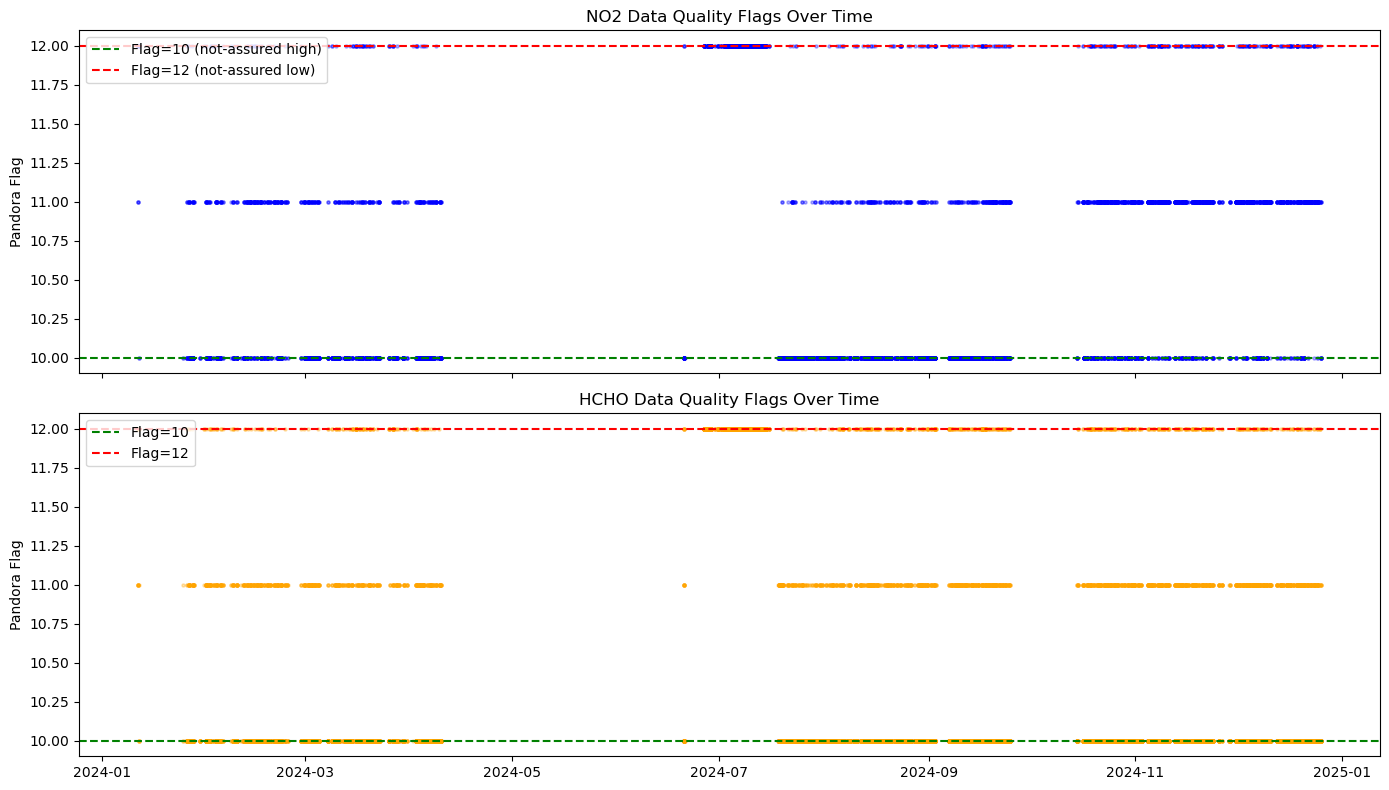

NO2 Flag distribution:
Pandora_Flag
10    4063
11    2297
12    1102
Name: count, dtype: int64

HCHO Flag distribution:
Pandora_Flag
10    10069
11     2607
12     1918
Name: count, dtype: int64


In [5]:
# Parse time columns
hcho_df['Pandora_time'] = pd.to_datetime(hcho_df['Pandora_time']).dt.tz_localize(None)
no2_df['Pandora_time'] = pd.to_datetime(no2_df['Pandora_time']).dt.tz_localize(None)

# Plot quality flags over time for both gases
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# NO2 flags over time
axes[0].scatter(no2_df['Pandora_time'], no2_df['Pandora_Flag'], 
               alpha=0.3, s=5, c='blue')
axes[0].set_ylabel('Pandora Flag')
axes[0].set_title('NO2 Data Quality Flags Over Time')
axes[0].axhline(y=10, color='green', linestyle='--', label='Flag=10 (not-assured high)')
axes[0].axhline(y=12, color='red', linestyle='--', label='Flag=12 (not-assured low)')
axes[0].legend()

# HCHO flags over time
axes[1].scatter(hcho_df['Pandora_time'], hcho_df['Pandora_Flag'], 
               alpha=0.3, s=5, c='orange')
axes[1].set_ylabel('Pandora Flag')
axes[1].set_title('HCHO Data Quality Flags Over Time')
axes[1].axhline(y=10, color='green', linestyle='--', label='Flag=10')
axes[1].axhline(y=12, color='red', linestyle='--', label='Flag=12')
axes[1].legend()

plt.tight_layout()
plt.savefig('quality_flags_over_time.png', dpi=150)
plt.show()

# Summary statistics of flags
print("NO2 Flag distribution:")
print(no2_df['Pandora_Flag'].value_counts().sort_index())
print("\nHCHO Flag distribution:")
print(hcho_df['Pandora_Flag'].value_counts().sort_index())

In [6]:
# Filter to recommended data only
hcho_clean = hcho_df[hcho_df['Recommended_For_Main_Scatterplots'] == True].copy()
no2_clean = no2_df[no2_df['Recommended_For_Main_Scatterplots'] == True].copy()

print(f"HCHO: {len(hcho_clean)}/{len(hcho_df)} rows recommended ({100*len(hcho_clean)/len(hcho_df):.1f}%)")
print(f"NO2: {len(no2_clean)}/{len(no2_df)} rows recommended ({100*len(no2_clean)/len(no2_df):.1f}%)")

HCHO: 12606/14594 rows recommended (86.4%)
NO2: 6352/7462 rows recommended (85.1%)


/var/folders/91/tmzh46hs1_vghy7y94yp_4_w0000gn/T/ipykernel_50851/2375056036.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([weekday_aod, weekend_aod], labels=['Weekday', 'Weekend'])
/var/folders/91/tmzh46hs1_vghy7y94yp_4_w0000gn/T/ipykernel_50851/2375056036.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([weekday_aod, weekend_aod], labels=['Weekday', 'Weekend'])



HCHO dataset - AOD 500nm:
  Weekday mean: 0.0675
  Weekend mean: 0.0656
  Difference: -2.8%

NO2 dataset - AOD 500nm:
  Weekday mean: 0.0680
  Weekend mean: 0.0657
  Difference: -3.3%


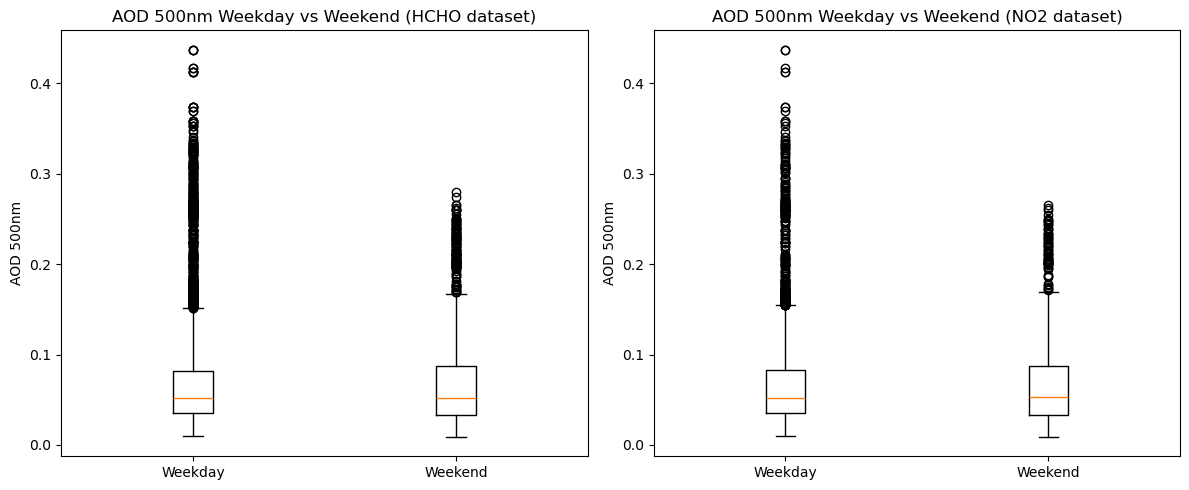

/var/folders/91/tmzh46hs1_vghy7y94yp_4_w0000gn/T/ipykernel_50851/2375056036.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([weekday_ae, weekend_ae], labels=['Weekday', 'Weekend'])
/var/folders/91/tmzh46hs1_vghy7y94yp_4_w0000gn/T/ipykernel_50851/2375056036.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([weekday_ae, weekend_ae], labels=['Weekday', 'Weekend'])


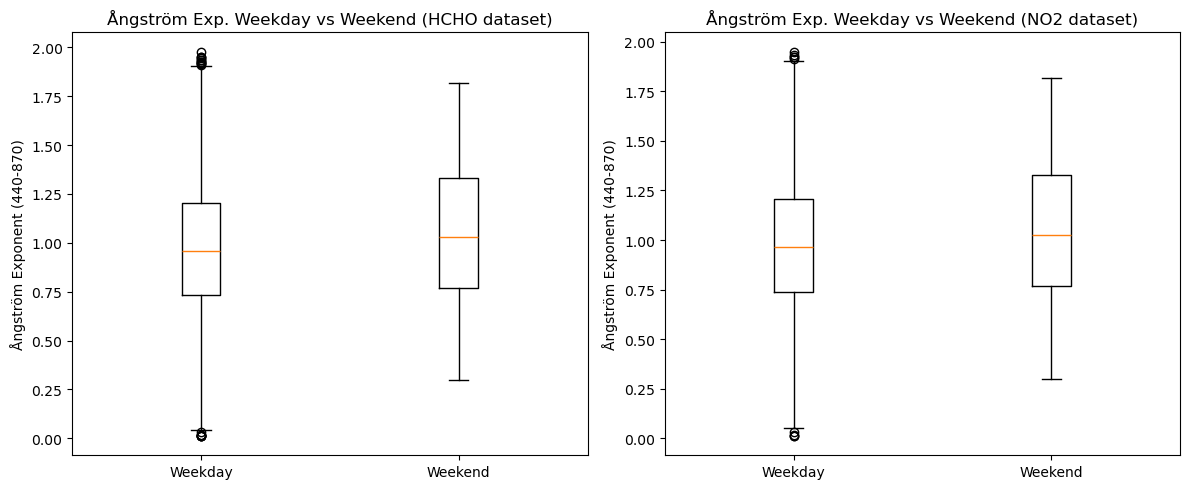

In [7]:
# Add day of week
hcho_clean['day_of_week'] = hcho_clean['Pandora_time'].dt.dayofweek
hcho_clean['is_weekend'] = hcho_clean['day_of_week'].isin([5, 6])

no2_clean['day_of_week'] = no2_clean['Pandora_time'].dt.dayofweek
no2_clean['is_weekend'] = no2_clean['day_of_week'].isin([5, 6])

# Plot AOD weekday vs weekend
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# AOD 500nm by day type
for df, label, ax in [(hcho_clean, 'HCHO dataset', axes[0]), 
                       (no2_clean, 'NO2 dataset', axes[1])]:
    weekday_aod = df[~df['is_weekend']]['AERONET_AOD_500nm'].dropna()
    weekend_aod = df[df['is_weekend']]['AERONET_AOD_500nm'].dropna()
    
    ax.boxplot([weekday_aod, weekend_aod], labels=['Weekday', 'Weekend'])
    ax.set_ylabel('AOD 500nm')
    ax.set_title(f'AOD 500nm Weekday vs Weekend ({label})')
    
    # Print means
    print(f"\n{label} - AOD 500nm:")
    print(f"  Weekday mean: {weekday_aod.mean():.4f}")
    print(f"  Weekend mean: {weekend_aod.mean():.4f}")
    print(f"  Difference: {(weekend_aod.mean() - weekday_aod.mean())/weekday_aod.mean()*100:.1f}%")

plt.tight_layout()
plt.savefig('aod_weekday_weekend.png', dpi=150)
plt.show()

# Same for Angstrom Exponent
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for df, label, ax in [(hcho_clean, 'HCHO dataset', axes[0]), 
                       (no2_clean, 'NO2 dataset', axes[1])]:
    weekday_ae = df[~df['is_weekend']]['AERONET_440-870_Angstrom_Exponent'].dropna()
    weekend_ae = df[df['is_weekend']]['AERONET_440-870_Angstrom_Exponent'].dropna()
    
    ax.boxplot([weekday_ae, weekend_ae], labels=['Weekday', 'Weekend'])
    ax.set_ylabel('Ångström Exponent (440-870)')
    ax.set_title(f'Ångström Exp. Weekday vs Weekend ({label})')

plt.tight_layout()
plt.savefig('angstrom_weekday_weekend.png', dpi=150)
plt.show()

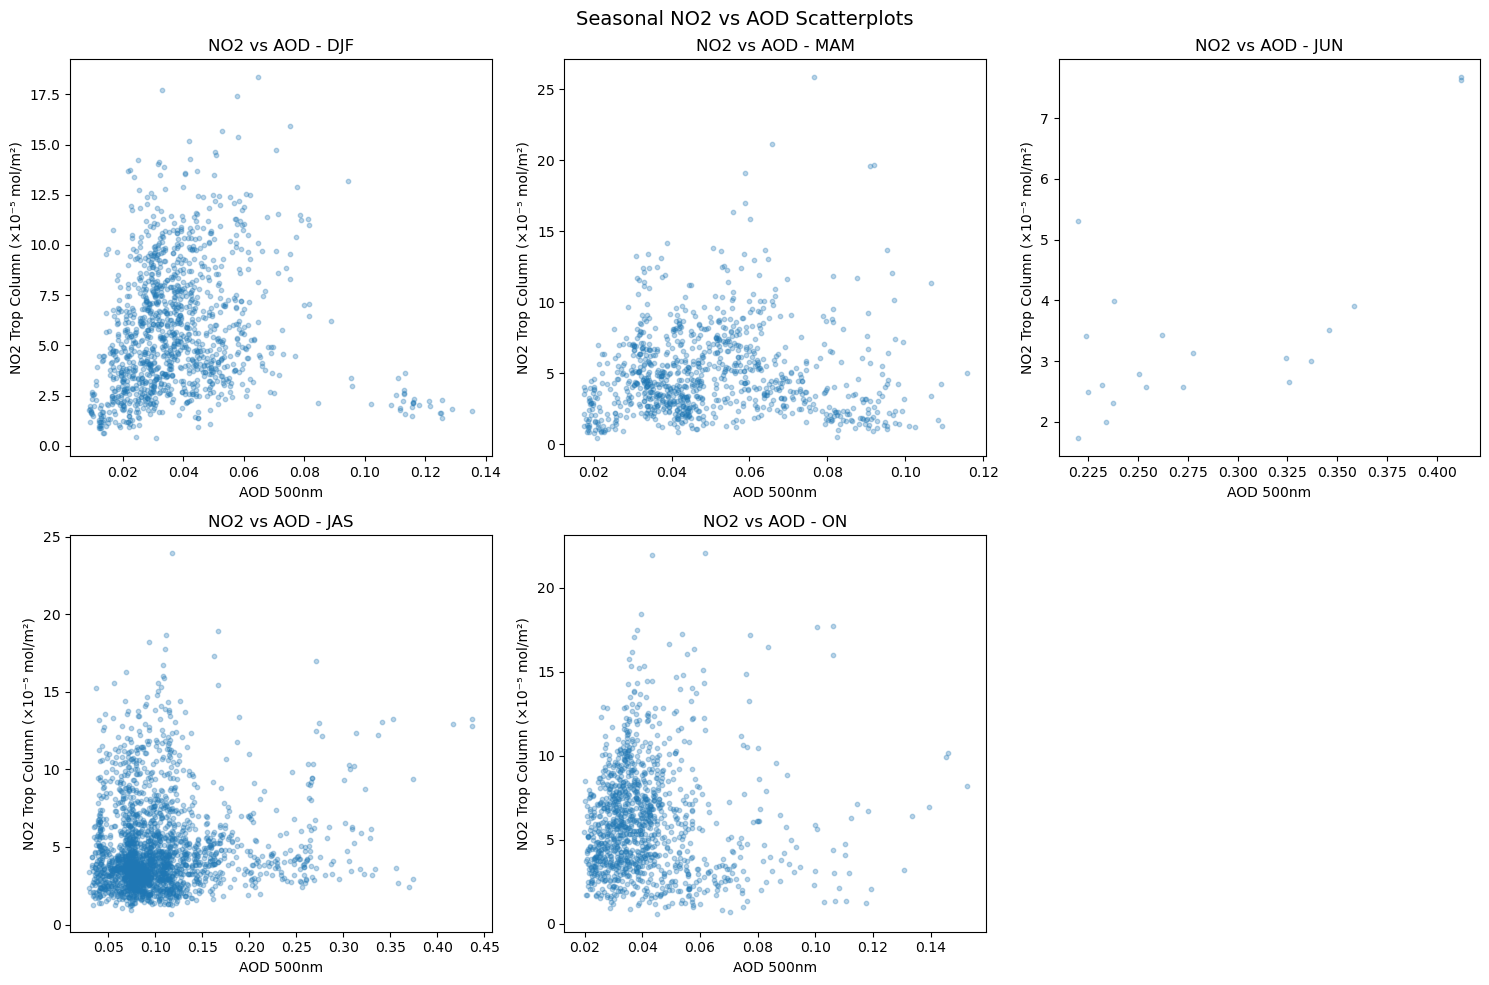

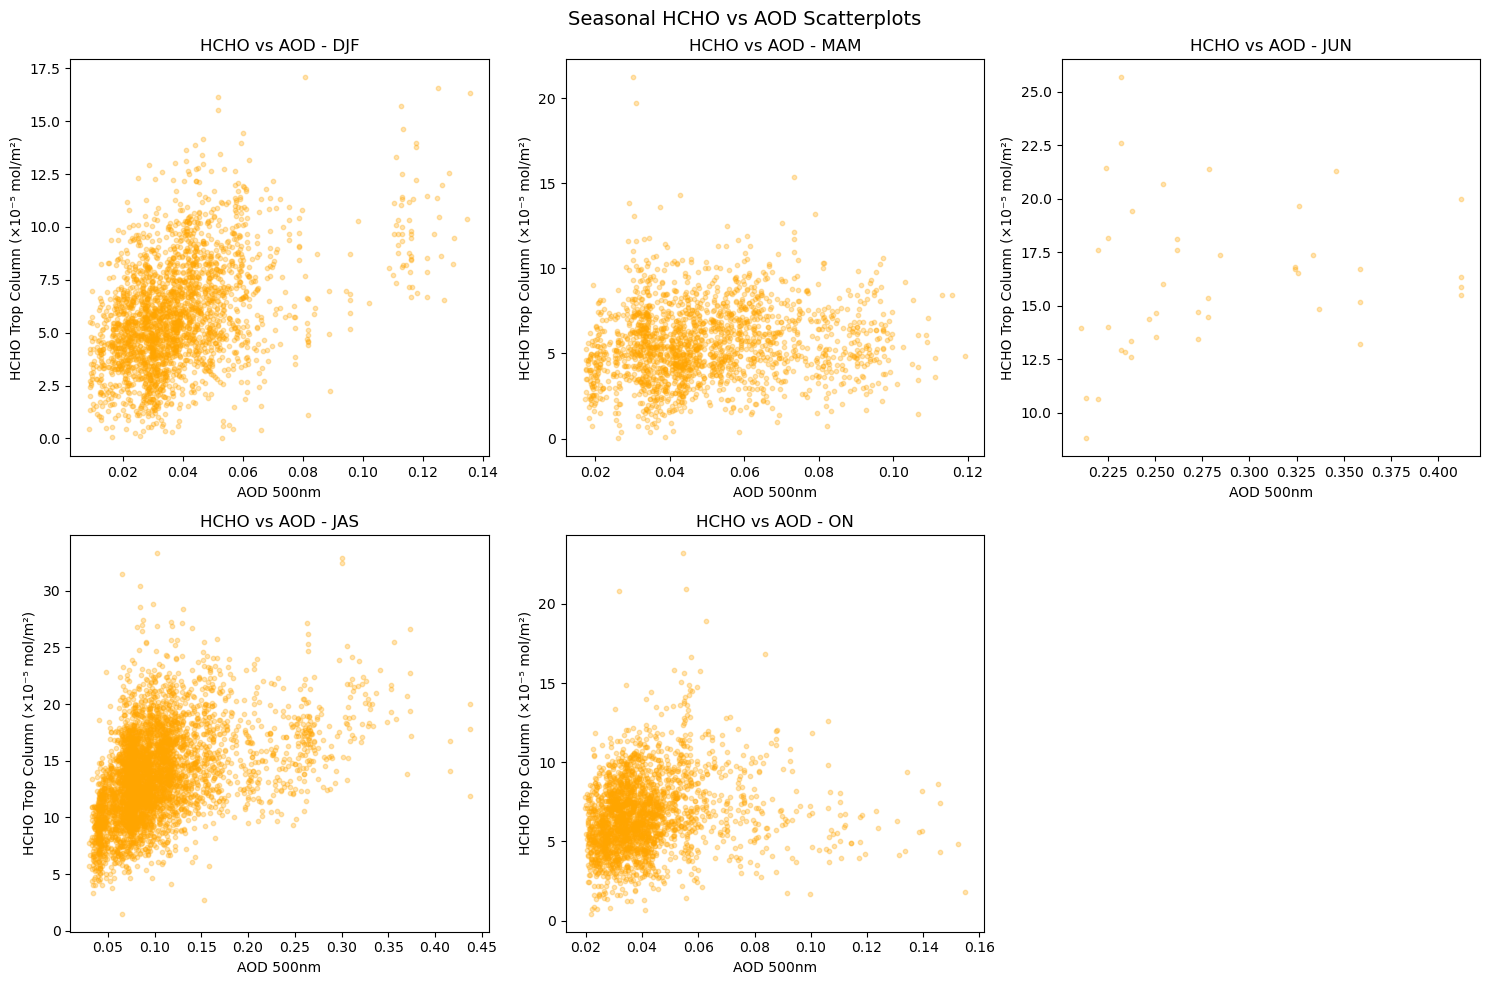

NO2 seasons: ['DJF' nan 'MAM' 'JUN' 'JAS' 'ON']
HCHO seasons: ['DJF' nan 'MAM' 'JUN' 'JAS' 'ON']


In [14]:
seasons = ['DJF', 'MAM', 'JUN', 'JAS', 'ON']

# NO2 vs AOD by season
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, season in enumerate(seasons):
    ax = axes[i]
    subset = no2_clean[no2_clean['Season'] == season]
    
    # Get the NO2 column name (adjust based on your actual column name)
    no2_col = [c for c in subset.columns if 'Nitrogen dioxide tropospheric vertical column' in c][0]
    
    ax.scatter(subset['AERONET_AOD_500nm'], 
              subset[no2_col] * 1e5,  # Convert to more readable units
              alpha=0.3, s=10)
    ax.set_xlabel('AOD 500nm')
    ax.set_ylabel('NO2 Trop Column (×10⁻⁵ mol/m²)')
    ax.set_title(f'NO2 vs AOD - {season}')

axes[-1].axis('off')
plt.suptitle('Seasonal NO2 vs AOD Scatterplots', fontsize=14)
plt.tight_layout()
plt.savefig('no2_vs_aod_seasonal.png', dpi=150)
plt.show()

# HCHO vs AOD by season
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, season in enumerate(seasons):
    ax = axes[i]
    subset = hcho_clean[hcho_clean['Season'] == season]
    
    hcho_col = [c for c in subset.columns if 'Formaldehyde tropospheric vertical column' in c][0]
    
    ax.scatter(subset['AERONET_AOD_500nm'], 
              subset[hcho_col] * 1e5,
              alpha=0.3, s=10, color='orange')
    ax.set_xlabel('AOD 500nm')
    ax.set_ylabel('HCHO Trop Column (×10⁻⁵ mol/m²)')
    ax.set_title(f'HCHO vs AOD - {season}')

axes[-1].axis('off')
plt.suptitle('Seasonal HCHO vs AOD Scatterplots', fontsize=14)
plt.tight_layout()
plt.savefig('hcho_vs_aod_seasonal.png', dpi=150)
plt.show()

# Similarly for Angstrom Exponent
# (repeat the above pattern with 'AERONET_440-870_Angstrom_Exponent' on x-axis)

print("NO2 seasons:", no2_clean['Season'].unique())
print("HCHO seasons:", hcho_clean['Season'].unique())

In [15]:
# Split data into lower and higher AOD using median
for df, gas_name in [(no2_clean, 'NO2'), (hcho_clean, 'HCHO')]:
    aod_median = df['AERONET_AOD_500nm'].median()
    df['AOD_category'] = np.where(df['AERONET_AOD_500nm'] <= aod_median, 
                                   'Low AOD', 'High AOD')
    
    # Get the gas column
    if gas_name == 'NO2':
        gas_col = [c for c in df.columns if 'Nitrogen dioxide tropospheric vertical column' in c][0]
    else:
        gas_col = [c for c in df.columns if 'Formaldehyde tropospheric vertical column' in c][0]
    
    print(f"\n{'='*60}")
    print(f"{gas_name} Weekend Effect by AOD Condition")
    print(f"{'='*60}")
    print(f"AOD median: {aod_median:.4f}")
    
    for aod_cat in ['Low AOD', 'High AOD']:
        subset = df[df['AOD_category'] == aod_cat]
        weekday_mean = subset[~subset['is_weekend']][gas_col].mean()
        weekend_mean = subset[subset['is_weekend']][gas_col].mean()
        pct_change = (weekend_mean - weekday_mean) / weekday_mean * 100
        
        print(f"\n  {aod_cat}:")
        print(f"    Weekday mean: {weekday_mean:.4e}")
        print(f"    Weekend mean: {weekend_mean:.4e}")
        print(f"    Weekend change: {pct_change:.1f}%")

# Same analysis with Angstrom Exponent
for df, gas_name in [(no2_clean, 'NO2'), (hcho_clean, 'HCHO')]:
    ae_median = df['AERONET_440-870_Angstrom_Exponent'].median()
    df['AE_category'] = np.where(df['AERONET_440-870_Angstrom_Exponent'] <= ae_median, 
                                  'Low AE (coarse)', 'High AE (fine)')
    
    if gas_name == 'NO2':
        gas_col = [c for c in df.columns if 'Nitrogen dioxide tropospheric vertical column' in c][0]
    else:
        gas_col = [c for c in df.columns if 'Formaldehyde tropospheric vertical column' in c][0]
    
    print(f"\n{'='*60}")
    print(f"{gas_name} Weekend Effect by Ångström Exponent Condition")
    print(f"{'='*60}")
    
    for ae_cat in ['Low AE (coarse)', 'High AE (fine)']:
        subset = df[df['AE_category'] == ae_cat]
        weekday_mean = subset[~subset['is_weekend']][gas_col].mean()
        weekend_mean = subset[subset['is_weekend']][gas_col].mean()
        pct_change = (weekend_mean - weekday_mean) / weekday_mean * 100
        
        print(f"\n  {ae_cat}:")
        print(f"    Weekend change: {pct_change:.1f}%")


NO2 Weekend Effect by AOD Condition
AOD median: 0.0523

  Low AOD:
    Weekday mean: 5.9641e-05
    Weekend mean: 4.5900e-05
    Weekend change: -23.0%

  High AOD:
    Weekday mean: 5.3631e-05
    Weekend mean: 4.2287e-05
    Weekend change: -21.2%

HCHO Weekend Effect by AOD Condition
AOD median: 0.0515

  Low AOD:
    Weekday mean: 6.3350e-05
    Weekend mean: 5.3771e-05
    Weekend change: -15.1%

  High AOD:
    Weekday mean: 1.2124e-04
    Weekend mean: 1.1833e-04
    Weekend change: -2.4%

NO2 Weekend Effect by Ångström Exponent Condition

  Low AE (coarse):
    Weekend change: -16.8%

  High AE (fine):
    Weekend change: -26.6%

HCHO Weekend Effect by Ångström Exponent Condition

  Low AE (coarse):
    Weekend change: -7.7%

  High AE (fine):
    Weekend change: -8.8%


In [16]:
# Check quality flags and uncertainties for different AOD levels
for df, gas_name in [(no2_clean, 'NO2'), (hcho_clean, 'HCHO')]:
    
    print(f"\n{'='*60}")
    print(f"{gas_name}: Quality Metrics by AOD Category")
    print(f"{'='*60}")
    
    for aod_cat in ['Low AOD', 'High AOD']:
        subset = df[df['AOD_category'] == aod_cat]
        
        print(f"\n  {aod_cat} (n={len(subset)}):")
        print(f"    Mean Pandora Flag: {subset['Pandora_Flag'].mean():.2f}")
        print(f"    Flag distribution:")
        print(subset['Pandora_Flag'].value_counts().sort_index().to_string())
        print(f"    Mean Abs Time Diff (min): {subset['Abs_Time_Difference_Minutes'].mean():.2f}")
        
        # Atmospheric variability
        atm_var_col = [c for c in subset.columns if 'Atmospheric variability' in c][0]
        print(f"    Mean Atmospheric Variability: {subset[atm_var_col].mean():.1f}%")


NO2: Quality Metrics by AOD Category

  Low AOD (n=3176):
    Mean Pandora Flag: 10.53
    Flag distribution:
Pandora_Flag
10    1484
11    1692
    Mean Abs Time Diff (min): 2.07
    Mean Atmospheric Variability: 25.1%

  High AOD (n=3176):
    Mean Pandora Flag: 10.19
    Flag distribution:
Pandora_Flag
10    2571
11     605
    Mean Abs Time Diff (min): 2.24
    Mean Atmospheric Variability: 30.9%

HCHO: Quality Metrics by AOD Category

  Low AOD (n=6303):
    Mean Pandora Flag: 10.23
    Flag distribution:
Pandora_Flag
10    4878
11    1425
    Mean Abs Time Diff (min): 2.07
    Mean Atmospheric Variability: 27.6%

  High AOD (n=6303):
    Mean Pandora Flag: 10.18
    Flag distribution:
Pandora_Flag
10    5165
11    1138
    Mean Abs Time Diff (min): 2.31
    Mean Atmospheric Variability: 32.1%


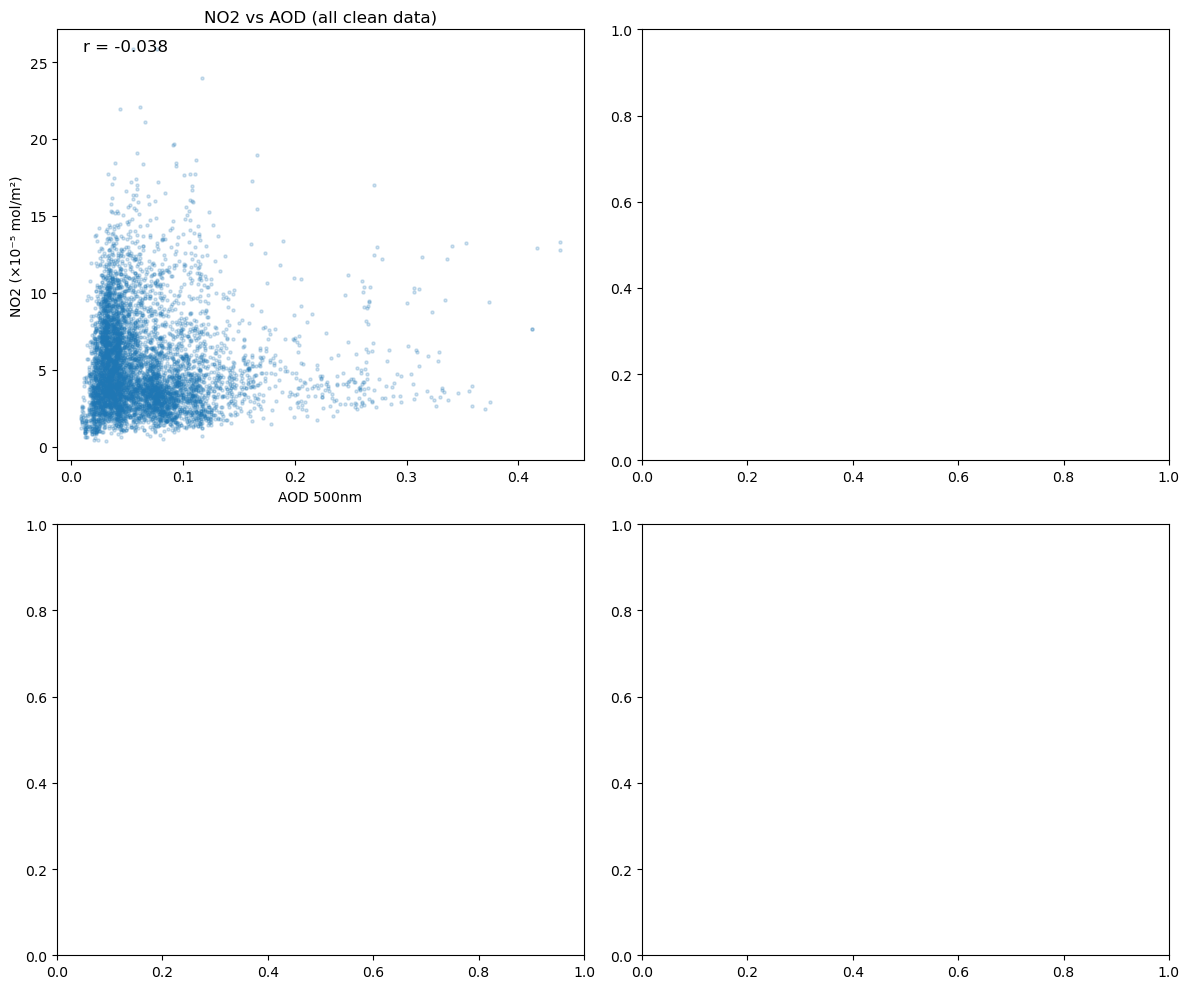

In [17]:
# Create a summary comparison plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: NO2 weekend drop by season AND AOD condition
# Plot 2: HCHO weekend change by season AND AOD condition
# Plot 3: Correlation between AOD and gas columns
# Plot 4: Time series of AOD colored by season

# Example: Correlation plot
ax = axes[0, 0]
no2_col = [c for c in no2_clean.columns if 'Nitrogen dioxide tropospheric vertical column' in c][0]
ax.scatter(no2_clean['AERONET_AOD_500nm'], no2_clean[no2_col] * 1e5, 
          alpha=0.2, s=5)
ax.set_xlabel('AOD 500nm')
ax.set_ylabel('NO2 (×10⁻⁵ mol/m²)')
ax.set_title('NO2 vs AOD (all clean data)')

# Add correlation coefficient
mask = no2_clean['AERONET_AOD_500nm'].notna() & no2_clean[no2_col].notna()
r = np.corrcoef(no2_clean.loc[mask, 'AERONET_AOD_500nm'], 
                no2_clean.loc[mask, no2_col])[0, 1]
ax.text(0.05, 0.95, f'r = {r:.3f}', transform=ax.transAxes, fontsize=12)

plt.tight_layout()
plt.savefig('interpretation_summary.png', dpi=150)
plt.show()

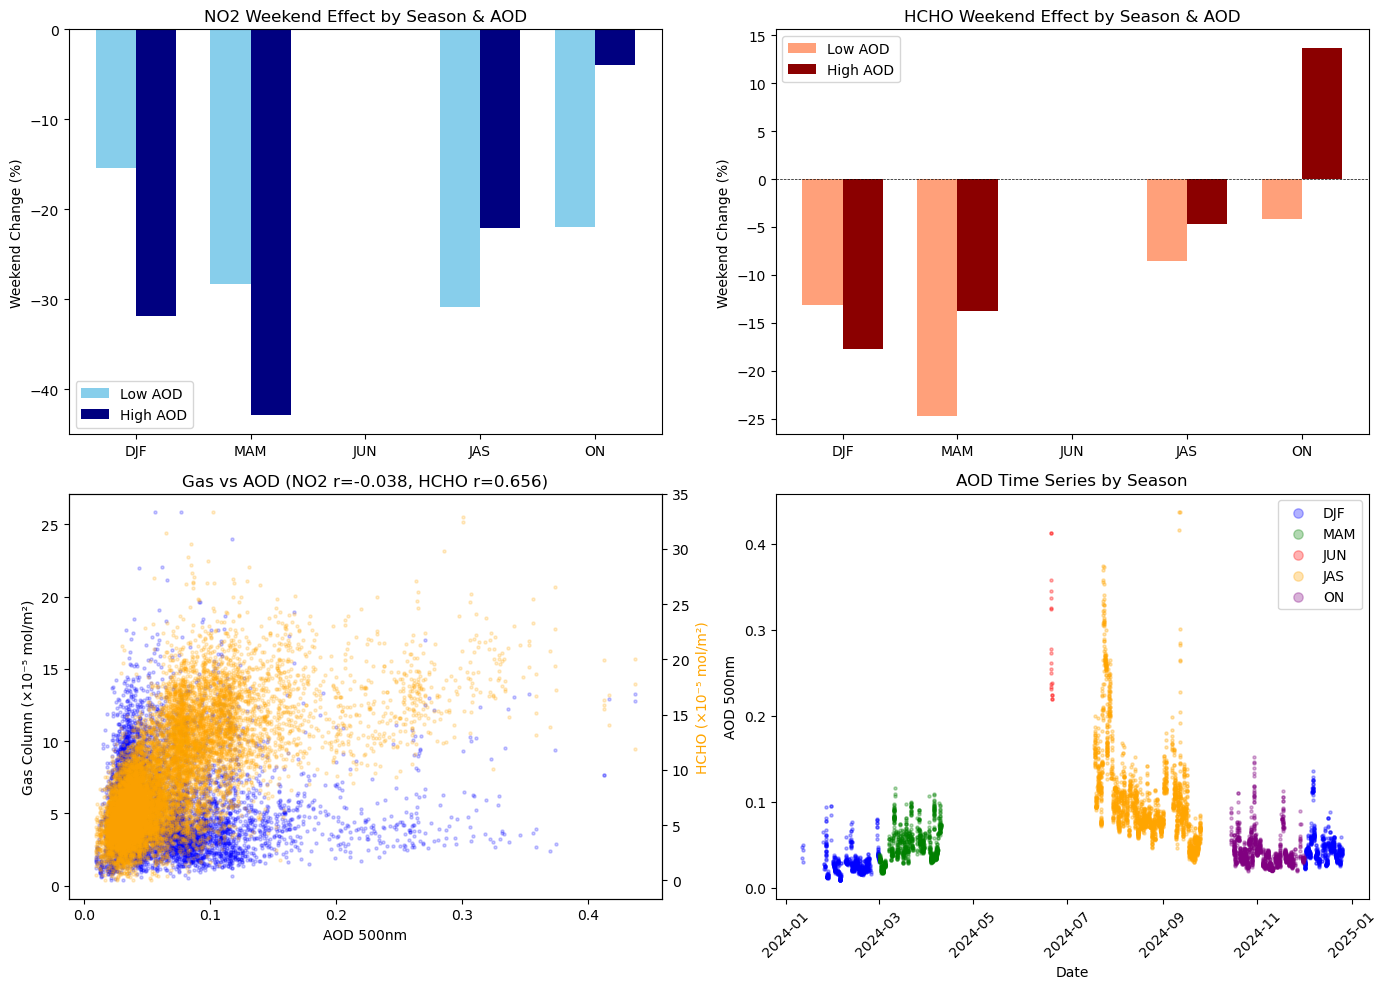

In [19]:
# Create a summary comparison plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Get column names
no2_col = [c for c in no2_clean.columns if 'Nitrogen dioxide tropospheric vertical column' in c][0]
hcho_col = [c for c in hcho_clean.columns if 'Formaldehyde tropospheric vertical column' in c][0]

seasons = ['DJF', 'MAM', 'JUN', 'JAS', 'ON']

# --- Plot 1: NO2 weekend drop by season AND AOD condition ---
ax = axes[0, 0]
aod_median = no2_clean['AERONET_AOD_500nm'].median()
no2_clean['AOD_category'] = np.where(no2_clean['AERONET_AOD_500nm'] <= aod_median, 
                                      'Low AOD', 'High AOD')

weekend_changes_low = []
weekend_changes_high = []
for season in seasons:
    for aod_cat, change_list in [('Low AOD', weekend_changes_low), ('High AOD', weekend_changes_high)]:
        subset = no2_clean[(no2_clean['Season'] == season) & (no2_clean['AOD_category'] == aod_cat)]
        weekday_mean = subset[~subset['is_weekend']][no2_col].mean()
        weekend_mean = subset[subset['is_weekend']][no2_col].mean()
        pct_change = (weekend_mean - weekday_mean) / weekday_mean * 100 if weekday_mean != 0 else np.nan
        change_list.append(pct_change)

x = np.arange(len(seasons))
width = 0.35
ax.bar(x - width/2, weekend_changes_low, width, label='Low AOD', color='skyblue')
ax.bar(x + width/2, weekend_changes_high, width, label='High AOD', color='navy')
ax.set_xticks(x)
ax.set_xticklabels(seasons)
ax.set_ylabel('Weekend Change (%)')
ax.set_title('NO2 Weekend Effect by Season & AOD')
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
ax.legend()

# --- Plot 2: HCHO weekend change by season AND AOD condition ---
ax = axes[0, 1]
aod_median_hcho = hcho_clean['AERONET_AOD_500nm'].median()
hcho_clean['AOD_category'] = np.where(hcho_clean['AERONET_AOD_500nm'] <= aod_median_hcho, 
                                       'Low AOD', 'High AOD')

weekend_changes_low = []
weekend_changes_high = []
for season in seasons:
    for aod_cat, change_list in [('Low AOD', weekend_changes_low), ('High AOD', weekend_changes_high)]:
        subset = hcho_clean[(hcho_clean['Season'] == season) & (hcho_clean['AOD_category'] == aod_cat)]
        weekday_mean = subset[~subset['is_weekend']][hcho_col].mean()
        weekend_mean = subset[subset['is_weekend']][hcho_col].mean()
        pct_change = (weekend_mean - weekday_mean) / weekday_mean * 100 if weekday_mean != 0 else np.nan
        change_list.append(pct_change)

x = np.arange(len(seasons))
ax.bar(x - width/2, weekend_changes_low, width, label='Low AOD', color='lightsalmon')
ax.bar(x + width/2, weekend_changes_high, width, label='High AOD', color='darkred')
ax.set_xticks(x)
ax.set_xticklabels(seasons)
ax.set_ylabel('Weekend Change (%)')
ax.set_title('HCHO Weekend Effect by Season & AOD')
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
ax.legend()

# --- Plot 3: Correlation between AOD and gas columns ---
ax = axes[1, 0]
# NO2 vs AOD
mask_no2 = no2_clean['AERONET_AOD_500nm'].notna() & no2_clean[no2_col].notna()
ax.scatter(no2_clean.loc[mask_no2, 'AERONET_AOD_500nm'], 
          no2_clean.loc[mask_no2, no2_col] * 1e5, 
          alpha=0.2, s=5, label='NO2', color='blue')
r_no2 = np.corrcoef(no2_clean.loc[mask_no2, 'AERONET_AOD_500nm'], 
                     no2_clean.loc[mask_no2, no2_col])[0, 1]
ax.set_xlabel('AOD 500nm')
ax.set_ylabel('Gas Column (×10⁻⁵ mol/m²)')
ax.set_title(f'NO2 vs AOD (r = {r_no2:.3f})')

# Add HCHO on secondary y-axis
ax2 = ax.twinx()
mask_hcho = hcho_clean['AERONET_AOD_500nm'].notna() & hcho_clean[hcho_col].notna()
ax2.scatter(hcho_clean.loc[mask_hcho, 'AERONET_AOD_500nm'], 
           hcho_clean.loc[mask_hcho, hcho_col] * 1e5, 
           alpha=0.2, s=5, label='HCHO', color='orange')
r_hcho = np.corrcoef(hcho_clean.loc[mask_hcho, 'AERONET_AOD_500nm'], 
                      hcho_clean.loc[mask_hcho, hcho_col])[0, 1]
ax2.set_ylabel('HCHO (×10⁻⁵ mol/m²)', color='orange')
ax.set_title(f'Gas vs AOD (NO2 r={r_no2:.3f}, HCHO r={r_hcho:.3f})')

# --- Plot 4: Time series of AOD colored by season ---
ax = axes[1, 1]
season_colors = {'DJF': 'blue', 'MAM': 'green', 'JUN': 'red', 'JAS': 'orange', 'ON': 'purple'}

for season in seasons:
    subset = no2_clean[no2_clean['Season'] == season]
    ax.scatter(subset['Pandora_time'], subset['AERONET_AOD_500nm'], 
              alpha=0.3, s=5, color=season_colors[season], label=season)

ax.set_xlabel('Date')
ax.set_ylabel('AOD 500nm')
ax.set_title('AOD Time Series by Season')
ax.legend(markerscale=3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('interpretation_summary.png', dpi=150)
plt.show()

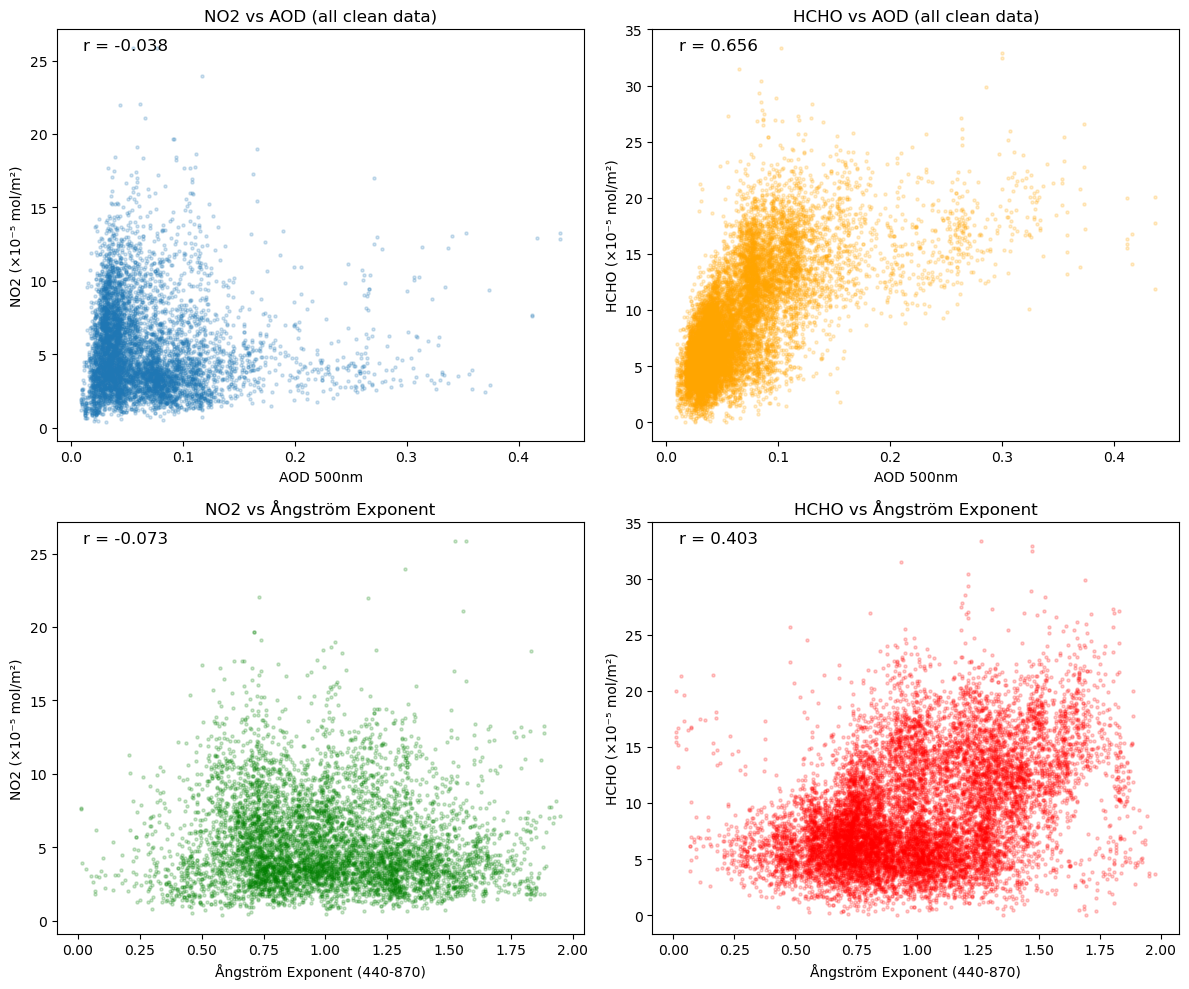

In [18]:
# Create a summary comparison plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Get column names
no2_col = [c for c in no2_clean.columns if 'Nitrogen dioxide tropospheric vertical column' in c][0]
hcho_col = [c for c in hcho_clean.columns if 'Formaldehyde tropospheric vertical column' in c][0]

# Plot 1: NO2 vs AOD correlation
ax = axes[0, 0]
ax.scatter(no2_clean['AERONET_AOD_500nm'], no2_clean[no2_col] * 1e5, 
          alpha=0.2, s=5)
ax.set_xlabel('AOD 500nm')
ax.set_ylabel('NO2 (×10⁻⁵ mol/m²)')
ax.set_title('NO2 vs AOD (all clean data)')
mask = no2_clean['AERONET_AOD_500nm'].notna() & no2_clean[no2_col].notna()
r = np.corrcoef(no2_clean.loc[mask, 'AERONET_AOD_500nm'], 
                no2_clean.loc[mask, no2_col])[0, 1]
ax.text(0.05, 0.95, f'r = {r:.3f}', transform=ax.transAxes, fontsize=12)

# Plot 2: HCHO vs AOD correlation
ax = axes[0, 1]
ax.scatter(hcho_clean['AERONET_AOD_500nm'], hcho_clean[hcho_col] * 1e5, 
          alpha=0.2, s=5, color='orange')
ax.set_xlabel('AOD 500nm')
ax.set_ylabel('HCHO (×10⁻⁵ mol/m²)')
ax.set_title('HCHO vs AOD (all clean data)')
mask = hcho_clean['AERONET_AOD_500nm'].notna() & hcho_clean[hcho_col].notna()
r = np.corrcoef(hcho_clean.loc[mask, 'AERONET_AOD_500nm'], 
                hcho_clean.loc[mask, hcho_col])[0, 1]
ax.text(0.05, 0.95, f'r = {r:.3f}', transform=ax.transAxes, fontsize=12)

# Plot 3: NO2 vs Angstrom Exponent
ax = axes[1, 0]
ax.scatter(no2_clean['AERONET_440-870_Angstrom_Exponent'], no2_clean[no2_col] * 1e5, 
          alpha=0.2, s=5, color='green')
ax.set_xlabel('Ångström Exponent (440-870)')
ax.set_ylabel('NO2 (×10⁻⁵ mol/m²)')
ax.set_title('NO2 vs Ångström Exponent')
mask = no2_clean['AERONET_440-870_Angstrom_Exponent'].notna() & no2_clean[no2_col].notna()
r = np.corrcoef(no2_clean.loc[mask, 'AERONET_440-870_Angstrom_Exponent'], 
                no2_clean.loc[mask, no2_col])[0, 1]
ax.text(0.05, 0.95, f'r = {r:.3f}', transform=ax.transAxes, fontsize=12)

# Plot 4: HCHO vs Angstrom Exponent
ax = axes[1, 1]
ax.scatter(hcho_clean['AERONET_440-870_Angstrom_Exponent'], hcho_clean[hcho_col] * 1e5, 
          alpha=0.2, s=5, color='red')
ax.set_xlabel('Ångström Exponent (440-870)')
ax.set_ylabel('HCHO (×10⁻⁵ mol/m²)')
ax.set_title('HCHO vs Ångström Exponent')
mask = hcho_clean['AERONET_440-870_Angstrom_Exponent'].notna() & hcho_clean[hcho_col].notna()
r = np.corrcoef(hcho_clean.loc[mask, 'AERONET_440-870_Angstrom_Exponent'], 
                hcho_clean.loc[mask, hcho_col])[0, 1]
ax.text(0.05, 0.95, f'r = {r:.3f}', transform=ax.transAxes, fontsize=12)

plt.tight_layout()
plt.savefig('interpretation_summary.png', dpi=150)
plt.show()

In [12]:
# Identify potential dust/smoke days based on AOD and Angstrom Exponent
# Dust: High AOD + Low Angstrom Exponent (coarse particles)
# Smoke: High AOD + High Angstrom Exponent (fine particles)

for df, gas_name in [(no2_clean, 'NO2'), (hcho_clean, 'HCHO')]:
    high_aod = df['AERONET_AOD_500nm'] > df['AERONET_AOD_500nm'].quantile(0.9)
    low_ae = df['AERONET_440-870_Angstrom_Exponent'] < 0.5
    high_ae = df['AERONET_440-870_Angstrom_Exponent'] > 1.5
    
    dust_days = df[high_aod & low_ae]['Pandora_time'].dt.date.unique()
    smoke_days = df[high_aod & high_ae]['Pandora_time'].dt.date.unique()
    
    print(f"\n{gas_name} dataset:")
    print(f"  Potential dust days (high AOD, low AE): {len(dust_days)}")
    if len(dust_days) > 0:
        print(f"    Examples: {dust_days[:5]}")
    print(f"  Potential smoke days (high AOD, high AE): {len(smoke_days)}")
    if len(smoke_days) > 0:
        print(f"    Examples: {smoke_days[:5]}")


NO2 dataset:
  Potential dust days (high AOD, low AE): 3
    Examples: [NaT datetime.date(2024, 6, 20) datetime.date(2024, 10, 29)]
  Potential smoke days (high AOD, high AE): 18
    Examples: [datetime.date(2024, 7, 20) NaT datetime.date(2024, 7, 21)
 datetime.date(2024, 7, 22) datetime.date(2024, 7, 23)]

HCHO dataset:
  Potential dust days (high AOD, low AE): 4
    Examples: [datetime.date(2024, 3, 11) NaT datetime.date(2024, 6, 20)
 datetime.date(2024, 10, 29)]
  Potential smoke days (high AOD, high AE): 18
    Examples: [datetime.date(2024, 7, 20) NaT datetime.date(2024, 7, 21)
 datetime.date(2024, 7, 22) datetime.date(2024, 7, 23)]
